# 04 — Group heterogeneity in detector-positive rates

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)

YEARS = list(range(2020, 2026))
N_BOOTSTRAP = 10_000
BOOTSTRAP_SEED = 20260723
DECISION_COLUMN = "finetuned_decision"
DETECTOR_POSITIVE_VALUE = 0

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        root
        for root in search_roots
        if (root / "data" / "processed" / "id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current directory."
    )

INPUT_CSV = REPO_ROOT / "data" / "processed" / "id_papers.csv"
SOURCE_DIR = REPO_ROOT / "data" / "source_data" / "04_group_heterogeneity"
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Input data: {INPUT_CSV}")
print(f"Source-data directory: {SOURCE_DIR}")

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Input data: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity


## Load and validate the analytical data


In [2]:
required_columns = {
    "id",
    "Year",
    DECISION_COLUMN,
    "first_author_academic_age",
    "first_author_language_environment",
    "track_type",
}
papers = pd.read_csv(INPUT_CSV, encoding="utf-8-sig", low_memory=False)
missing_columns = sorted(required_columns - set(papers.columns))
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

papers["Year"] = pd.to_numeric(papers["Year"], errors="coerce")
papers[DECISION_COLUMN] = pd.to_numeric(
    papers[DECISION_COLUMN], errors="coerce"
)
invalid_decisions = (
    papers["Year"].isin(YEARS)
    & papers[DECISION_COLUMN].notna()
    & ~papers[DECISION_COLUMN].isin([0, 1])
)
if invalid_decisions.any():
    raise ValueError(
        f"Found {int(invalid_decisions.sum()):,} invalid detector decisions."
    )

papers = papers.loc[
    papers["Year"].isin(YEARS)
    & papers[DECISION_COLUMN].isin([0, 1])
].copy()
papers["Year"] = papers["Year"].astype(int)
if papers["id"].duplicated().any():
    raise ValueError(
        f"Found {int(papers['id'].duplicated().sum()):,} duplicate paper IDs."
    )
papers["detector_positive"] = (
    papers[DECISION_COLUMN].eq(DETECTOR_POSITIVE_VALUE).astype(np.int8)
)

annual_overview = (
    papers.groupby("Year", as_index=False)
    .agg(
        n_papers=("id", "size"),
        n_detector_positive=("detector_positive", "sum"),
        detector_positive_rate=("detector_positive", "mean"),
    )
)
print(f"Eligible papers: {len(papers):,}")
display(annual_overview)

Eligible papers: 91,856


,Year,n_papers,n_detector_positive,detector_positive_rate
0,2020,10030,146,0.014556
1,2021,10983,172,0.015661
2,2022,11749,178,0.015150
3,2023,15724,1044,0.066395
4,2024,18789,5336,0.283996
5,2025,24581,13058,0.531223


## Define groups and bootstrap confidence intervals

In [3]:
DIMENSIONS = {
    "academic_age": {
        "label": "First-author academic age",
        "categories": ["0–3 years", "4–10 years", "11+ years"],
        "colors": ["#D9D2EA", "#9A86C8", "#574B8A"],
        "hatches": ["", "//", "xx"],
        "filename": "academic_age_detector_positive_rates.csv",
        "seed_offset": 0,
    },
    "language_environment": {
        "label": "First-author language environment",
        "categories": ["English", "Non-English"],
        "colors": ["#3775BA", "#D89164"],
        "hatches": ["", "//"],
        "filename": "language_environment_detector_positive_rates.csv",
        "seed_offset": 1_000,
    },
    "track_type": {
        "label": "Conference track type",
        "categories": ["Main track", "Non-main track"],
        "colors": ["#0F4D92", "#8BCF8B"],
        "hatches": ["", "//"],
        "filename": "track_type_detector_positive_rates.csv",
        "seed_offset": 2_000,
    },
}


def assign_groups(frame: pd.DataFrame, dimension: str) -> pd.Series:
    if dimension == "academic_age":
        age = pd.to_numeric(
            frame["first_author_academic_age"], errors="coerce"
        ).where(lambda values: values.between(0, 60))
        return pd.cut(
            age,
            bins=[-0.001, 3, 10, np.inf],
            labels=DIMENSIONS[dimension]["categories"],
            include_lowest=True,
            ordered=True,
        )

    if dimension == "language_environment":
        mapping = {
            "English_environment": "English",
            "Non_English_environment": "Non-English",
        }
        return (
            frame["first_author_language_environment"]
            .astype("string")
            .str.strip()
            .map(mapping)
        )

    if dimension == "track_type":
        mapping = {
            "main_track": "Main track",
            "non-main_track": "Non-main track",
            "non_main_track": "Non-main track",
        }
        return frame["track_type"].astype("string").str.strip().map(mapping)

    raise KeyError(f"Unknown dimension: {dimension}")


def bootstrap_binary_rate_ci(values, seed: int) -> tuple[float, float, float]:
    binary = np.asarray(values, dtype=np.int8)
    if binary.size == 0:
        return np.nan, np.nan, np.nan
    observed = float(binary.mean())
    rng = np.random.default_rng(seed)
    positive_counts = rng.binomial(
        n=binary.size,
        p=observed,
        size=N_BOOTSTRAP,
    )
    bootstrap_rates = positive_counts / binary.size
    lower, upper = np.percentile(bootstrap_rates, [2.5, 97.5])
    return observed, float(lower), float(upper)


print("Dimensions:", ", ".join(DIMENSIONS))
print(f"Bootstrap resamples per year–group cell: {N_BOOTSTRAP:,}")

Dimensions: academic_age, language_environment, track_type
Bootstrap resamples per year–group cell: 10,000


## Construct and save source-data tables

In [4]:
saved_source_files = []
dimension_summaries = []

for dimension_index, (dimension, spec) in enumerate(DIMENSIONS.items()):
    analysis = papers.copy()
    analysis["group"] = assign_groups(analysis, dimension)
    valid = analysis.loc[analysis["group"].notna()].copy()
    valid["group"] = pd.Categorical(
        valid["group"],
        categories=spec["categories"],
        ordered=True,
    )

    rows = []
    for year_index, year in enumerate(YEARS):
        annual_all = analysis.loc[analysis["Year"].eq(year)]
        annual_valid = valid.loc[valid["Year"].eq(year)]
        annual_positive = int(annual_valid["detector_positive"].sum())

        for group_index, category in enumerate(spec["categories"]):
            group = annual_valid.loc[annual_valid["group"].eq(category)]
            values = group["detector_positive"].to_numpy(dtype=np.int8)
            rate, lower, upper = bootstrap_binary_rate_ci(
                values,
                seed=(
                    BOOTSTRAP_SEED
                    + spec["seed_offset"]
                    + year_index * 100
                    + group_index
                ),
            )
            rows.append(
                {
                    "dimension": dimension,
                    "Year": year,
                    "group": category,
                    "n_papers": len(group),
                    "n_detector_positive": int(values.sum()),
                    "detector_positive_rate": rate,
                    "bootstrap_ci_lower": lower,
                    "bootstrap_ci_upper": upper,
                    "detector_positive_rate_percent": 100 * rate,
                    "bootstrap_ci_lower_percent": 100 * lower,
                    "bootstrap_ci_upper_percent": 100 * upper,
                    "year_total_all": len(annual_all),
                    "year_total_valid_for_dimension": len(annual_valid),
                    "year_excluded_missing_or_invalid": (
                        len(annual_all) - len(annual_valid)
                    ),
                    "year_detector_positive_valid_for_dimension": annual_positive,
                    "n_bootstrap": N_BOOTSTRAP,
                    "bootstrap_seed": (
                        BOOTSTRAP_SEED
                        + spec["seed_offset"]
                        + year_index * 100
                        + group_index
                    ),
                }
            )

    summary = pd.DataFrame(rows)
    if summary["n_papers"].eq(0).any():
        empty_cells = summary.loc[
            summary["n_papers"].eq(0), ["Year", "group"]
        ].to_dict("records")
        raise ValueError(f"Empty cells for {dimension}: {empty_cells}")

    source_path = SOURCE_DIR / spec["filename"]
    summary.to_csv(source_path, index=False, encoding="utf-8-sig")
    saved_source_files.append(source_path)
    dimension_summaries.append(
        {
            "dimension": dimension,
            "n_valid_papers": len(valid),
            "n_excluded": len(analysis) - len(valid),
            "n_detector_positive": int(valid["detector_positive"].sum()),
            "source_file": source_path.name,
        }
    )
    print(f"Saved {dimension}: {source_path}")
    display(summary)

dimension_summary = pd.DataFrame(dimension_summaries)
dimension_summary_path = SOURCE_DIR / "dimension_sample_summary.csv"
dimension_summary.to_csv(
    dimension_summary_path, index=False, encoding="utf-8-sig"
)
saved_source_files.append(dimension_summary_path)
print("Dimension-specific sample summary:")
display(dimension_summary)

Saved academic_age: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/academic_age_detector_positive_rates.csv


,dimension,Year,group,n_papers,n_detector_positive,detector_positive_rate,bootstrap_ci_lower,bootstrap_ci_upper,detector_positive_rate_percent,bootstrap_ci_lower_percent,bootstrap_ci_upper_percent,year_total_all,year_total_valid_for_dimension,year_excluded_missing_or_invalid,year_detector_positive_valid_for_dimension,n_bootstrap,bootstrap_seed
0,academic_age,2020,0–3 years,2598,41,0.015781,0.011162,0.020785,1.578137,1.116243,2.078522,10030,9613,417,140,10000,20260723
1,academic_age,2020,4–10 years,2722,51,0.018736,0.013960,0.024247,1.873622,1.396032,2.424688,10030,9613,417,140,10000,20260724
2,academic_age,2020,11+ years,4293,48,0.011181,0.008153,0.014442,1.118099,0.815281,1.444212,10030,9613,417,140,10000,20260725
3,academic_age,2021,0–3 years,2852,48,0.016830,0.012272,0.021739,1.683029,1.227209,2.173913,10983,10625,358,168,10000,20260823
4,academic_age,2021,4–10 years,3010,53,0.017608,0.013281,0.022591,1.760797,1.328073,2.259136,10983,10625,358,168,10000,20260824
5,academic_age,2021,11+ years,4763,67,0.014067,0.010708,0.017426,1.406676,1.070754,1.742599,10983,10625,358,168,10000,20260825
6,academic_age,2022,0–3 years,2944,44,0.014946,0.010870,0.019361,1.494565,1.086957,1.936141,11749,11029,720,169,10000,20260923
7,academic_age,2022,4–10 years,2966,57,0.019218,0.014498,0.024275,1.921780,1.449764,2.427512,11749,11029,720,169,10000,20260924
8,academic_age,2022,11+ years,5119,68,0.013284,0.010354,0.016409,1.328384,1.035358,1.640945,11749,11029,720,169,10000,20260925
9,academic_age,2023,0–3 years,3867,308,0.079648,0.071115,0.088441,7.964831,7.111456,8.844065,15724,14695,1029,981,10000,20261023


Saved language_environment: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/language_environment_detector_positive_rates.csv


,dimension,Year,group,n_papers,n_detector_positive,detector_positive_rate,bootstrap_ci_lower,bootstrap_ci_upper,detector_positive_rate_percent,bootstrap_ci_lower_percent,bootstrap_ci_upper_percent,year_total_all,year_total_valid_for_dimension,year_excluded_missing_or_invalid,year_detector_positive_valid_for_dimension,n_bootstrap,bootstrap_seed
0,language_environment,2020,English,4083,86,0.021063,0.016899,0.025478,2.106294,1.689934,2.547759,10030,8845,1185,130,10000,20261723
1,language_environment,2020,Non-English,4762,44,0.009240,0.006510,0.011970,0.923982,0.650987,1.196976,10030,8845,1185,130,10000,20261724
2,language_environment,2021,English,4343,101,0.023256,0.018881,0.027861,2.325581,1.888096,2.786093,10983,9856,1127,156,10000,20261823
3,language_environment,2021,Non-English,5513,55,0.009976,0.007437,0.012697,0.997642,0.743697,1.269726,10983,9856,1127,156,10000,20261824
4,language_environment,2022,English,3291,70,0.021270,0.016408,0.026436,2.127013,1.640839,2.643573,11749,8589,3160,116,10000,20261923
5,language_environment,2022,Non-English,5298,46,0.008683,0.006229,0.011325,0.868252,0.622877,1.132503,11749,8589,3160,116,10000,20261924
6,language_environment,2023,English,4009,319,0.079571,0.071339,0.088052,7.957097,7.133949,8.805188,15724,11100,4624,767,10000,20262023
7,language_environment,2023,Non-English,7091,448,0.063179,0.057679,0.068961,6.317868,5.767875,6.896065,15724,11100,4624,767,10000,20262024
8,language_environment,2024,English,2392,631,0.263796,0.246656,0.281773,26.379599,24.665552,28.177258,18789,7998,10791,2140,10000,20262123
9,language_environment,2024,Non-English,5606,1509,0.269176,0.257581,0.280949,26.917588,25.758116,28.094898,18789,7998,10791,2140,10000,20262124


Saved track_type: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/track_type_detector_positive_rates.csv


,dimension,Year,group,n_papers,n_detector_positive,detector_positive_rate,bootstrap_ci_lower,bootstrap_ci_upper,detector_positive_rate_percent,bootstrap_ci_lower_percent,bootstrap_ci_upper_percent,year_total_all,year_total_valid_for_dimension,year_excluded_missing_or_invalid,year_detector_positive_valid_for_dimension,n_bootstrap,bootstrap_seed
0,track_type,2020,Main track,7774,113,0.014536,0.011963,0.017237,1.453563,1.196295,1.723694,10030,10030,0,146,10000,20262723
1,track_type,2020,Non-main track,2256,33,0.014628,0.009752,0.019947,1.462766,0.975177,1.994681,10030,10030,0,146,10000,20262724
2,track_type,2021,Main track,8390,127,0.015137,0.012515,0.017878,1.513707,1.251490,1.787843,10983,10983,0,172,10000,20262823
3,track_type,2021,Non-main track,2593,45,0.017354,0.012341,0.022754,1.735442,1.234092,2.275357,10983,10983,0,172,10000,20262824
4,track_type,2022,Main track,8827,132,0.014954,0.012462,0.017560,1.495412,1.246177,1.755976,11749,11749,0,178,10000,20262923
5,track_type,2022,Non-main track,2922,46,0.015743,0.011294,0.020534,1.574264,1.129363,2.053388,11749,11749,0,178,10000,20262924
6,track_type,2023,Main track,11126,565,0.050782,0.046827,0.054827,5.078195,4.682725,5.482653,15724,15724,0,1044,10000,20263023
7,track_type,2023,Non-main track,4598,479,0.104176,0.095476,0.113093,10.417573,9.547629,11.309265,15724,15724,0,1044,10000,20263024
8,track_type,2024,Main track,14191,3769,0.265591,0.258474,0.272919,26.559087,25.847368,27.291946,18789,18789,0,5336,10000,20263123
9,track_type,2024,Non-main track,4598,1567,0.340800,0.327316,0.354502,34.080035,32.731622,35.450196,18789,18789,0,5336,10000,20263124


Dimension-specific sample summary:


,dimension,n_valid_papers,n_excluded,n_detector_positive,source_file
0,academic_age,83443,8413,17262,academic_age_detector_positive_rates.csv
1,language_environment,53955,37901,7530,language_environment_detector_positive_rates.csv
2,track_type,91856,0,19934,track_type_detector_positive_rates.csv


## Plotting function

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator, PercentFormatter

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "legend.fontsize": 9.5,
        "legend.frameon": False,
        "axes.linewidth": 0.8,
        "figure.facecolor": "white",
    }
)


def plot_group_rates(source_path: Path, spec: dict):
    source = pd.read_csv(source_path, encoding="utf-8-sig")
    expected_rows = len(YEARS) * len(spec["categories"])
    if len(source) != expected_rows:
        raise ValueError(
            f"Expected {expected_rows} rows in {source_path.name}, found {len(source)}."
        )

    fig, ax_rate = plt.subplots(figsize=(7.5, 4.7))
    ax_volume = ax_rate.twinx()
    x = np.arange(len(YEARS), dtype=float)
    n_groups = len(spec["categories"])
    total_bar_width = 0.72
    bar_width = total_bar_width / n_groups

    for group_index, (category, color, hatch) in enumerate(
        zip(spec["categories"], spec["colors"], spec["hatches"])
    ):
        group = (
            source.loc[source["group"].eq(category)]
            .set_index("Year")
            .reindex(YEARS)
        )
        rate = group["detector_positive_rate_percent"].to_numpy(float)
        lower = group["bootstrap_ci_lower_percent"].to_numpy(float)
        upper = group["bootstrap_ci_upper_percent"].to_numpy(float)
        offset = (group_index - (n_groups - 1) / 2) * bar_width

        ax_rate.bar(
            x + offset,
            rate,
            width=bar_width * 0.92,
            yerr=np.vstack([rate - lower, upper - rate]),
            color=color,
            edgecolor="#333333",
            linewidth=0.45,
            hatch=hatch,
            capsize=2.5,
            error_kw={
                "ecolor": "#333333",
                "elinewidth": 0.9,
                "capthick": 0.9,
            },
            zorder=3,
        )

    annual_volume = (
        source.groupby("Year")["year_detector_positive_valid_for_dimension"]
        .first()
        .reindex(YEARS)
        .to_numpy(dtype=int)
    )
    volume_color = "#686868"
    ax_volume.plot(
        x,
        annual_volume,
        color=volume_color,
        marker="o",
        markerfacecolor="white",
        markeredgecolor=volume_color,
        markeredgewidth=1.2,
        markersize=5,
        linewidth=1.6,
        linestyle="--",
        zorder=4,
    )

    maximum_ci = float(np.nanmax(source["bootstrap_ci_upper_percent"]))
    rate_upper = min(
        100.0,
        max(5.0, np.ceil((maximum_ci + 3.0) / 5.0) * 5.0),
    )
    maximum_volume = int(annual_volume.max())
    volume_step = max(500, int(np.ceil(maximum_volume / 5_000)) * 500)
    volume_upper = max(
        volume_step,
        np.ceil(
            (maximum_volume + max(100, maximum_volume * 0.08)) / volume_step
        )
        * volume_step,
    )
    ax_rate.set_ylim(0, rate_upper)
    ax_volume.set_ylim(0, volume_upper)

    ax_rate.set_xticks(x)
    ax_rate.set_xticklabels(YEARS)
    ax_rate.set_xlabel("Publication year")
    ax_rate.set_ylabel("Detector-positive rate (%)")
    ax_volume.set_ylabel(
        "Number of detector-positive abstracts", color=volume_color
    )
    ax_rate.yaxis.set_major_locator(MultipleLocator(5))
    ax_rate.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax_volume.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{int(value):,}")
    )
    ax_volume.tick_params(axis="y", colors=volume_color)
    ax_rate.tick_params(axis="both", length=3, width=0.8)
    ax_rate.grid(
        axis="y",
        color="#D8D8D8",
        linewidth=0.6,
        linestyle="--",
        alpha=0.75,
        zorder=0,
    )
    ax_rate.set_axisbelow(True)
    ax_rate.spines["top"].set_visible(False)
    ax_volume.spines["top"].set_visible(False)
    ax_volume.spines["right"].set_color(volume_color)

    handles = [
        Patch(
            facecolor=color,
            edgecolor="#333333",
            linewidth=0.45,
            hatch=hatch,
            label=category,
        )
        for category, color, hatch in zip(
            spec["categories"], spec["colors"], spec["hatches"]
        )
    ]
    handles.append(
        Line2D(
            [0],
            [0],
            color=volume_color,
            marker="o",
            markerfacecolor="white",
            linestyle="--",
            linewidth=1.6,
            label="Detector-positive abstracts",
        )
    )
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.88),
        ncol=min(3, len(handles)),
        columnspacing=1.15,
        handlelength=1.6,
        handletextpad=0.45,
    )
    fig.subplots_adjust(left=0.11, right=0.87, bottom=0.13, top=0.80)
    plt.show()
    plt.close(fig)
    return source



## First-author academic age

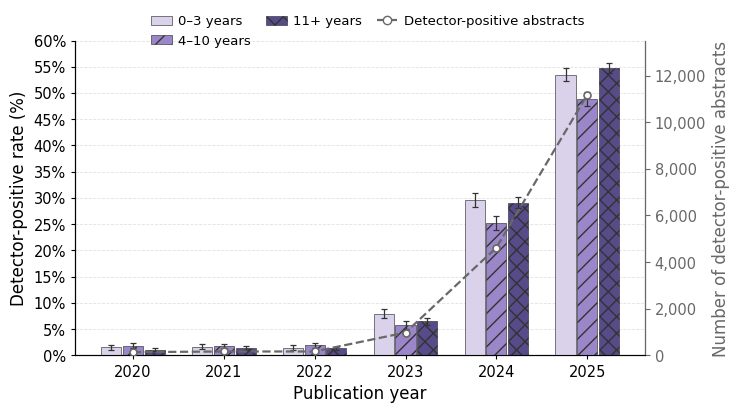

Displayed academic-age figure from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/academic_age_detector_positive_rates.csv


In [6]:
spec = DIMENSIONS["academic_age"]
academic_age_source = SOURCE_DIR / spec["filename"]
academic_age_plot_data = plot_group_rates(academic_age_source, spec)
print(f"Displayed academic-age figure from: {academic_age_source}")

## First-author language environment

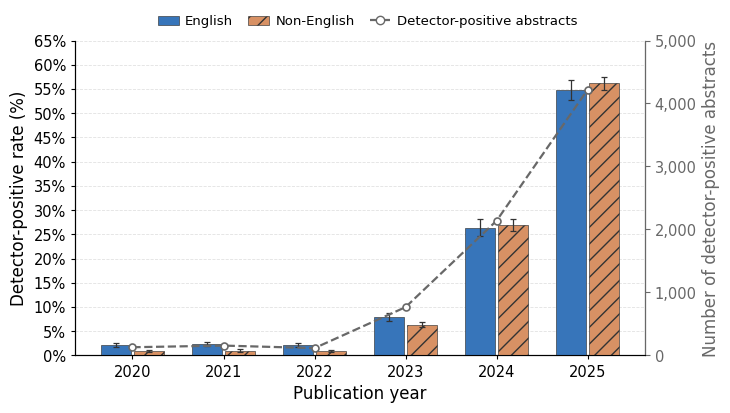

Displayed language-environment figure from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/language_environment_detector_positive_rates.csv


In [7]:
spec = DIMENSIONS["language_environment"]
language_source = SOURCE_DIR / spec["filename"]
language_plot_data = plot_group_rates(language_source, spec)
print(f"Displayed language-environment figure from: {language_source}")

## Conference track type

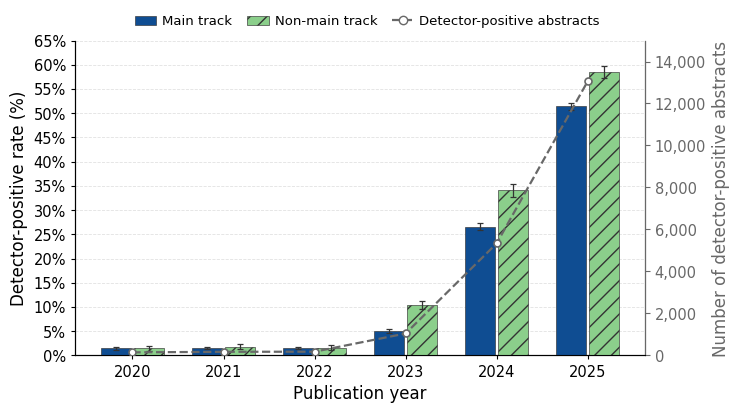

Displayed track-type figure from: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/04_group_heterogeneity/track_type_detector_positive_rates.csv


In [8]:
spec = DIMENSIONS["track_type"]
track_source = SOURCE_DIR / spec["filename"]
track_plot_data = plot_group_rates(track_source, spec)
print(f"Displayed track-type figure from: {track_source}")